In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import DistanceMetric
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.neighbors import KNeighborsClassifier

import skfda
from skfda.ml.classification import KNeighborsClassifier



In [ ]:
import numpy as np
import skfda
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Load height dataset
X, y = skfda.datasets.fetch_growth(return_X_y=True, as_frame=True)
X = X.iloc[:, 0].values  # Extract functional data

# Define colors
light_gray = "#D3D3D3"  # Light gray for individual curves
blue = "#1f77b4"  # Blue for the mean curve
green = "#2ca02c"  # Green for the constant line
red = "#d62728"  # Red for the functional mean


def tuple_range(t):
    return max(t) - min(t)
rng = tuple_range(X.domain_range[0])
# Compute constant height
cte = X.mean().integrate().ravel()
cte_value = cte / rng
print(cte_value)

# Create figure and axis
fig, ax = plt.subplots(figsize=(8, 6))

# Plot all curves in light gray on the same axis
X.plot(axes=ax, color=light_gray, linewidth=0.5, zorder=0)

# Plot mean curve in blue on the same axis
X.mean().plot(axes=ax, color=blue, linewidth=2, label="Continuous mean", zorder=10)

from skfda.exploratory.stats._stats import individual_observation_mean, grand_mean

print(individual_observation_mean(X))
print(grand_menan(X))

# Plot constant height line in green
ax.axhline(cte_value, color=green, linestyle="--", linewidth=2, label="Constant mean")

# Add legend
handles = [
    Line2D([0], [0], color=light_gray, linewidth=0.5, label="Individual curves"),
    Line2D([0], [0], color=blue, linewidth=2, label="Functional mean"),
    Line2D([0], [0], color=green, linestyle="--", linewidth=2, label="Grand mean")
]
ax.legend(handles=handles)

ax.set_xlim(X.domain_range[0][0], X.domain_range[0][1])
# Show plot
plt.show()


In [ ]:
y.categories

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    stratify=y,
    random_state=0,
)

In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

In [ ]:
pred = knn.predict(X_test)
print(pred)

In [ ]:
from sklearn.metrics import DistanceMetric
from skfda.misc.metrics import l2_distance

class myMetric(DistanceMetric):
    def __init__(self):
        super().__init__()
    
    def pairwise(self, X, Y = None):
        return l2_distance(X, Y)

my_metric = myMetric()

In [ ]:
from sklearn.neighbors import KNeighborsClassifier 
# Use it in KNeighborsClassifier 

neigh = KNeighborsClassifier(n_neighbors=2, metric=my_metric)
neigh.fit(X_train, y_train)

In [ ]:
X_df_test = pd.DataFrame(X_test)
neigh.predict(X_df_test)

---

From here on this will be the example of a Mixed Multivariate data distance calculation. The first thing I will do i create the dataframe with the data I will be using.



In [ ]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

from skfda import datasets
from skfda.exploratory.depth import IntegratedDepth, ModifiedBandDepth
from skfda.exploratory.visualization import Boxplot
from skfda.representation.grid import FDataGrid
from skfda.representation import FData
import pandas as pd

In [ ]:
X, y = datasets.fetch_weather(return_X_y=True, as_frame=True)
fd = X.iloc[:, 0].values
fd_temperatures = fd.coordinates[0]
fd_precipitations = fd.coordinates[1]
fd_temperatures.plot()
fd_precipitations.plot()

print()

In [ ]:
fd_temperatures.n_samples

In [ ]:
fd_temperatures.data_matrix.shape[1:]

In [ ]:
y.shape

In [ ]:
fd_D_temperatures = fd_temperatures.derivative(order=1)
fd_D_precipitations = fd_precipitations.derivative(order=1)

fd_D_temperatures.plot()
fd_D_precipitations.plot()
print()


In [ ]:
fd_D_temperatures.data_matrix.shape

In [ ]:
# Create a FDataGrid vector valued with a function and a derivative

data_matrix = np.concatenate([
    fd_temperatures.data_matrix,
    fd_D_temperatures.data_matrix,
], axis=2) 

fd_vector = FDataGrid(
    data_matrix=data_matrix,
    grid_points=fd_temperatures.grid_points,
)

# Plot the vector-valued function
fd_vector.plot()


Create the dataframe


In [ ]:
mixed_fd = pd.DataFrame(
    {
        "category": y,
        "temperatures": fd_temperatures,
        "temperature_derivatives": fd_D_temperatures,
        "precipitations_vector": fd_vector,
    }
)

In [ ]:
fd = mixed_fd["precipitations_vector"]

In [ ]:
mixed_fd.head()

In [ ]:
from skfda.exploratory.visualization.representation import plot_mixed_data

In [ ]:
plot_mixed_data(mixed_fd)


In [ ]:
from skfda.ml.classification import KNeighborsClassifier
from skfda.misc.metrics._pproduct_metric import PProductMetric
KNeighborsClassifier(
    n_neighbors=3,
    metric=PProductMetric(),
    
)

In [ ]:
import numpy as np
matriz_4x4 = np.random.rand(4, 4)

matriz_4x4

In [ ]:
matriz_4x4*np.array(13)

In [ ]:
# We want to create a multivariate fdata grid

grid_points = np.linspace(0, 1, 4)
data_matrix = np.zeros((4, 4, 4))
for i in range(4):
    for j in range(4):
        data_matrix[i, j] = matriz_4x4[i, j] * np.array(grid_points)

fdata = FDataGrid(
    data_matrix=data_matrix,
    grid_points=grid_points,
)
fdata[0].plot()

#plot only all the functions in the second dimention
fdata.plot()

# Create a FDataGrid with only the second dimension:
data_matrix = fdata.data_matrix[:, :, 0]
fdata_2d = FDataGrid(
    data_matrix=data_matrix,
    grid_points=grid_points,
).plot()

In [ ]:
len(3)

---

Ejemplo escala

In [ ]:
import numpy as np

from skfda.representation import FDataGrid

fd1 = FDataGrid(data_matrix=np.ones((1,100)), grid_points=np.linspace(0,1,100))
fd2 = FDataGrid(data_matrix=np.ones((1,100)), grid_points=np.linspace(0,100,100))

In [ ]:
from skfda.preprocessing.scaler import compute_uniform_scale

scale1 = compute_uniform_scale(fd1)
scale2 = compute_uniform_scale(fd2)

In [ ]:
scale1, scale2

In [ ]:
from skfda.misc.metrics import l2_norm

print(l2_norm(fd1))
print(l2_norm(fd2))

Sacaling the data

In [ ]:
print(l2_norm(fd1/scale1))
print(l2_norm(fd2/scale2))

---

In [4]:
import numpy as np
import pandas as pd

from skfda.datasets import make_gaussian_process
from skfda.misc.metrics._pproduct_metric import PProductMetric
from skfda.ml.classification import KNeighborsClassifier

# Create sample FData
fd1 = make_gaussian_process(n_samples=10, random_state=0)
fd2 = make_gaussian_process(n_samples=10, random_state=1)
metric = PProductMetric(p=2)
# Combine into a DataFrame
X_df = pd.DataFrame({
    "component_1": fd1,
    "component_2": fd2,
})

# Create a binary target
y = np.array([0, 1] * 5)

""" # Initialize and fit the classifier
clf = KNeighborsClassifier(n_neighbors=3, metric=metric)
clf.fit(X_df, y)

# Predict on training data
y_pred = clf.predict(X_df)

# Check result
print("Predicted labels:", y_pred)
assert len(y_pred) == len(y), "Prediction length mismatch."
 """

' # Initialize and fit the classifier\nclf = KNeighborsClassifier(n_neighbors=3, metric=metric)\nclf.fit(X_df, y)\n\n# Predict on training data\ny_pred = clf.predict(X_df)\n\n# Check result\nprint("Predicted labels:", y_pred)\nassert len(y_pred) == len(y), "Prediction length mismatch."\n '

/tmp/ipykernel_67601/2924838020.py:1: FutureWarning: <class 'skfda.representation.grid.FDataGrid'>._reduce will require a `keepdims` parameter in the future
  X_df.mean()["component_1"].plot()


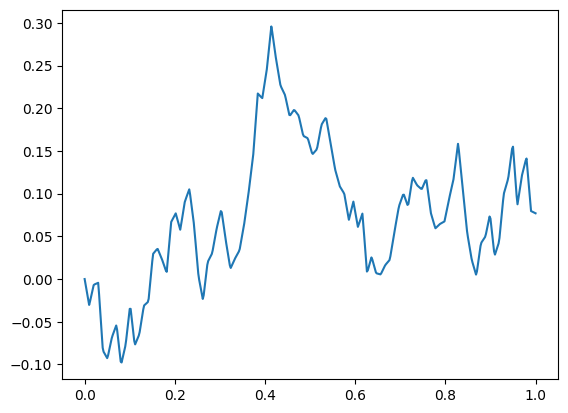

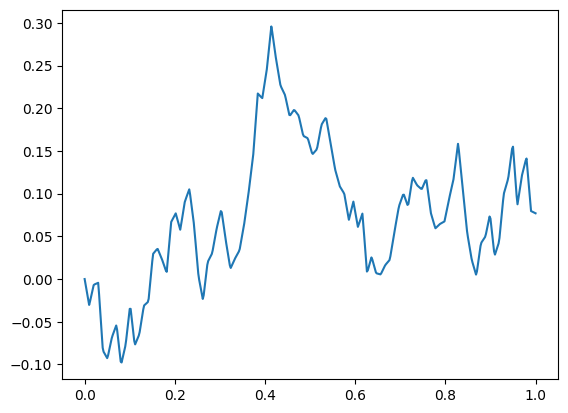

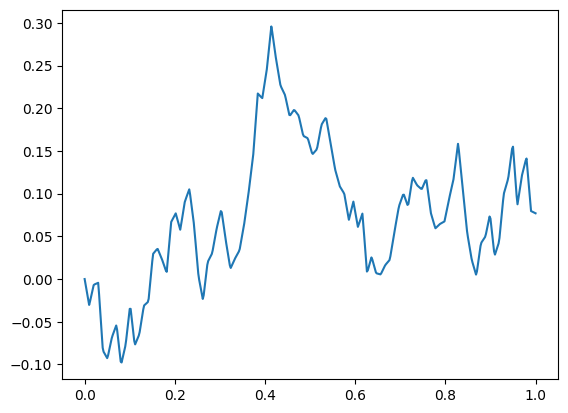

In [9]:
X_df.mean()["component_1"].plot()
fd1.mean().plot()


In [7]:
from skfda.exploratory.visualization.representation import plot_mixed_data
plot_mixed_data(X_df.mean())

/tmp/ipykernel_67601/976483622.py:2: FutureWarning: <class 'skfda.representation.grid.FDataGrid'>._reduce will require a `keepdims` parameter in the future
  plot_mixed_data(X_df.mean())


AttributeError: 'Series' object has no attribute 'columns'

<Figure size 640x480 with 0 Axes>